# 01 — Explore FMA Dataset

Before running: download and unzip fma_metadata.zip into `../data/fma_metadata/`

```bash
cd ../data
curl -O https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
unzip fma_metadata.zip -d fma_metadata
```

In [19]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from anther_ml.data import load_fma_tracks, load_fma_features, load_fma_genres

METADATA_DIR = '../data/fma_metadata'

pd.set_option('display.max_columns', 10)
print('imports ok')

imports ok


## Load tracks metadata

In [20]:
tracks = load_fma_tracks(METADATA_DIR)
print(f'Total tracks: {len(tracks)}')
print(f'Columns (top level): {tracks.columns.get_level_values(0).unique().tolist()}')
tracks.head(3)

Total tracks: 106574
Columns (top level): ['album', 'artist', 'set', 'track']


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   

                    ...    track                                      
         favorites  ... lyricist number publisher tags         title  
track_id            ...                                               
2                4  ...      NaN      3       NaN   []          Food  
3                4  ...      NaN      4       NaN   []  Electric Ave  
5                4  ...      NaN      6       NaN   []    This World  

[3 rows x 52 columns]

In [21]:
# How many tracks per subset?
tracks[('set', 'subset')].value_counts()

(set, subset)
large     81574
medium    17000
small      8000
Name: count, dtype: int64

In [ ]:
# Genre distribution in the small subset
# NOTE: 'subset' is a string column; `<= 'small'` compares alphabetically
# (large < medium < small) and silently matches ALL 106k tracks. Filter by
# exact membership instead — fma_small is the 8,000 tracks labeled 'small'.
small = tracks[tracks[('set', 'subset')] == 'small']
genre_counts = small[('track', 'genre_top')].value_counts()

fig, ax = plt.subplots(figsize=(12, 4))
genre_counts.plot(kind='bar', ax=ax)
ax.set_title(f'Top-level genre distribution (fma_small, {len(small)} tracks)')
ax.set_xlabel('Genre')
ax.set_ylabel('Track count')
plt.tight_layout()
plt.show()

print(f'fma_small tracks: {len(small)}   (expect 8000)')
print(f'Unique top-level genres: {genre_counts.shape[0]}')
print(genre_counts)

## Load pre-computed features

In [23]:
features = load_fma_features(METADATA_DIR, subset='small')
print(f'Features shape: {features.shape}')  # expect ~(8000, 518)
print(f'Feature groups: {features.columns.get_level_values(0).unique().tolist()}')
features.head(3)

Features shape: (106574, 518)
Feature groups: ['chroma_cens', 'chroma_cqt', 'chroma_stft', 'mfcc', 'rmse', 'spectral_bandwidth', 'spectral_centroid', 'spectral_contrast', 'spectral_rolloff', 'tonnetz', 'zcr']


feature    chroma_cens                                          ...       zcr  \
statistics    kurtosis                                          ...      mean   
number              01        02        03        04        05  ...        01   
track_id                                                        ...             
2             7.180653  5.230309  0.249321  1.347620  1.482478  ...  0.085629   
3             1.888963  0.760539  0.345297  2.295201  1.654031  ...  0.084578   
5             0.527563 -0.077654 -0.279610  0.685883  1.937570  ...  0.053114   

feature                                        
statistics    median  min      skew       std  
number            01   01        01        01  
track_id                                       
2           0.071289  0.0  2.089872  0.061448  
3           0.063965  0.0  1.716724  0.069330  
5           0.041504  0.0  2.193303  0.044861  

[3 rows x 518 columns]

In [24]:
# Check for missing values
na_count = features.isna().sum().sum()
print(f'NaN count: {na_count}')

# Drop rows with any NaN (corrupted or missing audio)
features_clean = features.dropna()
print(f'After drop: {features_clean.shape}')

NaN count: 0
After drop: (106574, 518)


In [25]:
# Align tracks with clean features (inner join on track_id)
common_ids = features_clean.index.intersection(small.index)
features_aligned = features_clean.loc[common_ids]
tracks_aligned = small.loc[common_ids]
genre_labels = tracks_aligned[('track', 'genre_top')].fillna('Unknown').tolist()

print(f'Aligned: {len(common_ids)} tracks ready for clustering')

Aligned: 106574 tracks ready for clustering


## Feature distributions

Quick look at the MFCC means — the first few capture the most timbral energy.

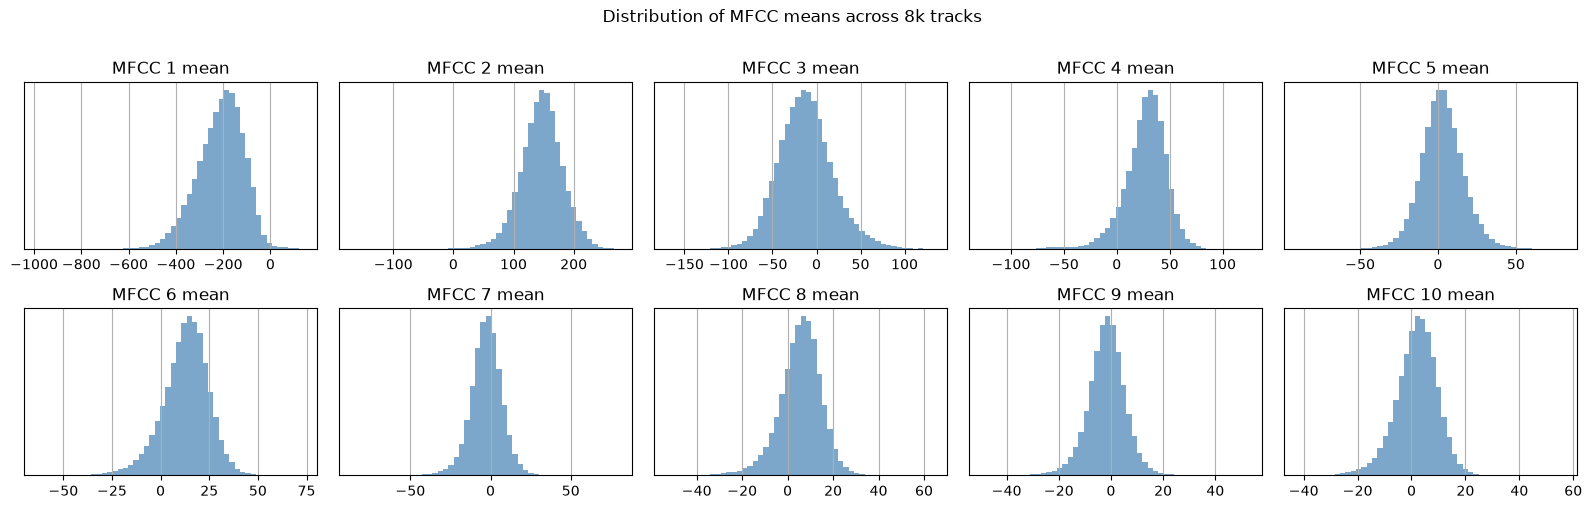

In [26]:
mfcc_means = features_aligned['mfcc'].xs('mean', level='statistics', axis=1)

fig, axes = plt.subplots(2, 5, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    if i >= mfcc_means.shape[1]:
        ax.axis('off')
        continue
    mfcc_means.iloc[:, i].hist(ax=ax, bins=50, color='steelblue', alpha=0.7)
    ax.set_title(f'MFCC {i+1} mean')
    ax.set_yticks([])

plt.suptitle('Distribution of MFCC means across 8k tracks', y=1.01)
plt.tight_layout()
plt.show()

In [27]:
# Save aligned data for notebook 02
import pickle

save = {
    'X': features_aligned.values.astype('float32'),
    'genre_labels': genre_labels,
    'track_ids': list(common_ids),
    'track_names': tracks_aligned[('track', 'title')].fillna('').tolist(),
    'artist_names': tracks_aligned[('artist', 'name')].fillna('').tolist(),
}

with open('../models/fma_small_features.pkl', 'wb') as f:
    pickle.dump(save, f)

print(f'Saved {save["X"].shape[0]} tracks to models/fma_small_features.pkl')

Saved 106574 tracks to models/fma_small_features.pkl
